# DECOMP — Self-contained results

Cross-region shared-subspace analysis on the IBL Brain-Wide Map (2023_12 release).

> Are the movement signals carried by V1, cerebellum (CB), and motor cortex (MO) two views of a single low-dimensional global state inherited everywhere — or three distinct region-specific computations that share more than global arousal?

This notebook reproduces every result in [`docs/expansion_analysis.md`](../docs/expansion_analysis.md) end-to-end **from cached intermediate files** in `data/cache/` and the prerendered figures in `docs/figures/expansion/`. No IBL credentials, no spike-binning, no GLM refit, no SVCA refit are needed — every cell loads a CSV / `.npy` from cache, recomputes the headline statistic, and shows the figure that the main pipeline (`run_all.py`, `scripts/run_richz.py`, `scripts/run_dynamics.py`) produced from the same cache.

It is **structurally identical to `docs/expansion_analysis.md`** — the 7 numbered sections below mirror the 7 sections of that document, the figures are the same figures, and the verifying numbers are recomputed in code so you can verify the prose against the data without leaving the notebook.


## Setup

Load the cache, the prerendered figures, the per-session GLM / SVCA / CCA / richer-Z CSVs, and the summary JSON.


In [1]:
from __future__ import annotations
import json
import glob
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

# Resolve repo root from this notebook (notebooks/) so paths work no matter the CWD.
REPO = Path.cwd()
if REPO.name == 'notebooks':
    REPO = REPO.parent
CACHE = REPO / 'data' / 'cache'
FIGS  = REPO / 'docs' / 'figures' / 'expansion'
OUT   = REPO / 'outputs'

with open(OUT / 'summary.json') as f:
    SUMMARY = json.load(f)

print(f'Repo:    {REPO}')
print(f'GLM rows in this run: {SUMMARY["n_glm_rows"]}')
print(f'CCA per pair:         {SUMMARY["n_cca_rows_by_pair"]}')


Repo:    /Users/kevinb/Desktop/DECOMP
GLM rows in this run: 4886
CCA per pair:         {'CB:MO': 1, 'VIS:CB': 10, 'VIS:MO': 4}


In [2]:
def load_all(suffix: str) -> pd.DataFrame:
    """Concatenate every cached CSV with the given filename suffix."""
    files = sorted(CACHE.glob(f'*_{suffix}.csv'))
    if not files:
        raise FileNotFoundError(f'no *_{suffix}.csv files in {CACHE}')
    return pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

glm  = load_all('glm_results')
svca = load_all('svca_summary')
cca  = load_all('cca_results')
rich = load_all('cca_richz')

print(f'GLM:  {len(glm):>5} per-neuron rows, {glm.eid.nunique():>3} sessions, regions={sorted(glm.region.unique())}')
print(f'SVCA: {len(svca):>5} per-region rows, {svca.eid.nunique():>3} sessions')
print(f'CCA:  {len(cca):>5} component rows,  {cca.eid.nunique():>3} sessions, pairs={sorted(set(zip(cca.pair_a, cca.pair_b)))}')
print(f'rich: {len(rich):>5} richer-Z rows,   {rich.eid.nunique():>3} sessions')


GLM:   4886 per-neuron rows,  51 sessions, regions=['CA1', 'CB', 'MO', 'VISp']
SVCA:    30 per-region rows,  15 sessions
CCA:    113 component rows,   15 sessions, pairs=[('CB', 'MO'), ('VIS', 'CB'), ('VIS', 'MO')]
rich:   113 richer-Z rows,    15 sessions


## Bottom line (from `expansion_analysis.md`)

In **fifteen** dual-region recordings spanning visual cortex (VIS), motor cortex (MO), and cerebellum (CB), the cross-region linear shared subspace **survives partialling out wheel velocity + pupil diameter on every session**: median ratio of partialled to raw summed canonical correlations is ≈ 0.97 for all three pairs. Read in isolation, that argues interregional coupling is largely orthogonal to global movement state. A **richer partial** — adding wheel acceleration, whisker and body motion energy, and lick rate — walks the ratio back to **0.69–0.85** (median, by pair), demonstrating that 10–30 percentage points of the apparent orthogonality were uninstructed-movement signals that wheel+pupil failed to capture. The remaining 0.7–0.85 persists even under the richer behavioural probe.

Below, every number in that paragraph is recomputed from cache.


In [3]:
# Per-pair, per-session survival = sum(rho_pcca) / sum(rho_cca)
sums = (cca
        .groupby(['eid','pair_a','pair_b'])
        .agg(sum_cca=('rho_cca','sum'), sum_pcca=('rho_pcca','sum'))
        .reset_index())
sums['survival'] = sums.sum_pcca / sums.sum_cca

rich_sums = (rich
             .groupby(['eid','pair_a','pair_b'])
             .agg(sum_cca=('rho_cca','sum'),
                  sum_pcca_min=('rho_pcca_min','sum'),
                  sum_pcca_rich=('rho_pcca_rich','sum'))
             .reset_index())
rich_sums['survival_min']  = rich_sums.sum_pcca_min  / rich_sums.sum_cca
rich_sums['survival_rich'] = rich_sums.sum_pcca_rich / rich_sums.sum_cca

headline = (rich_sums
            .groupby(['pair_a','pair_b'])
            .agg(n_sessions=('eid','nunique'),
                 survival_min=('survival_min','median'),
                 survival_rich=('survival_rich','median'))
            .round(3))
headline['drop'] = (headline.survival_min - headline.survival_rich).round(3)
headline


n_sessions  survival_min  survival_rich   drop
pair_a pair_b                                                
CB     MO               1         0.975          0.689  0.286
VIS    CB              10         0.973          0.854  0.119
       MO               4         0.977          0.757  0.220

Three pairs, three rows. `survival_min` is the wheel + pupil partial (the headline 0.97). `survival_rich` is the 5–6-D richer-Z partial. The `drop` column is exactly the 10–30 pp walk-back the bottom line describes.

---

## 1. Per-region encoding reproduces the published ranking

**What we are doing.** Per-neuron Ridge GLM with raised-cosine kernels for stimulus / first-movement / feedback / choice / prior / wheel / motion-energy / pupil regressors, on every neuron in the four ROI pools (VISp, CB, MO, CA1) — 4 886 neurons across 51 sessions, $\Delta t = 20$ ms bins. The per-neuron $\Delta R^2_\text{movement}$ is the variance of held-out spike count uniquely explained by the movement kernel group, computed leave-one-group-out under 5-fold KFold cross-validation.

**Why we are doing it.** A naive decoder yields a single scalar per region and cannot say *which* covariates a neuron is tuned to. The GLM gives a per-neuron, per-kernel unique contribution. The literature prior (IBL 2025; Wang–Druckmann 2026) is an ordering: movement encoding should be largest near the motor periphery (MO ≥ CB > VIS > CA1). Reproducing that ordering on our pipeline confirms our binning, design matrix construction, and ΔR² computation before we trust the cross-region inference downstream.

**Figure 1.** Per-region ΔR² distributions for movement, stim, choice kernel groups.


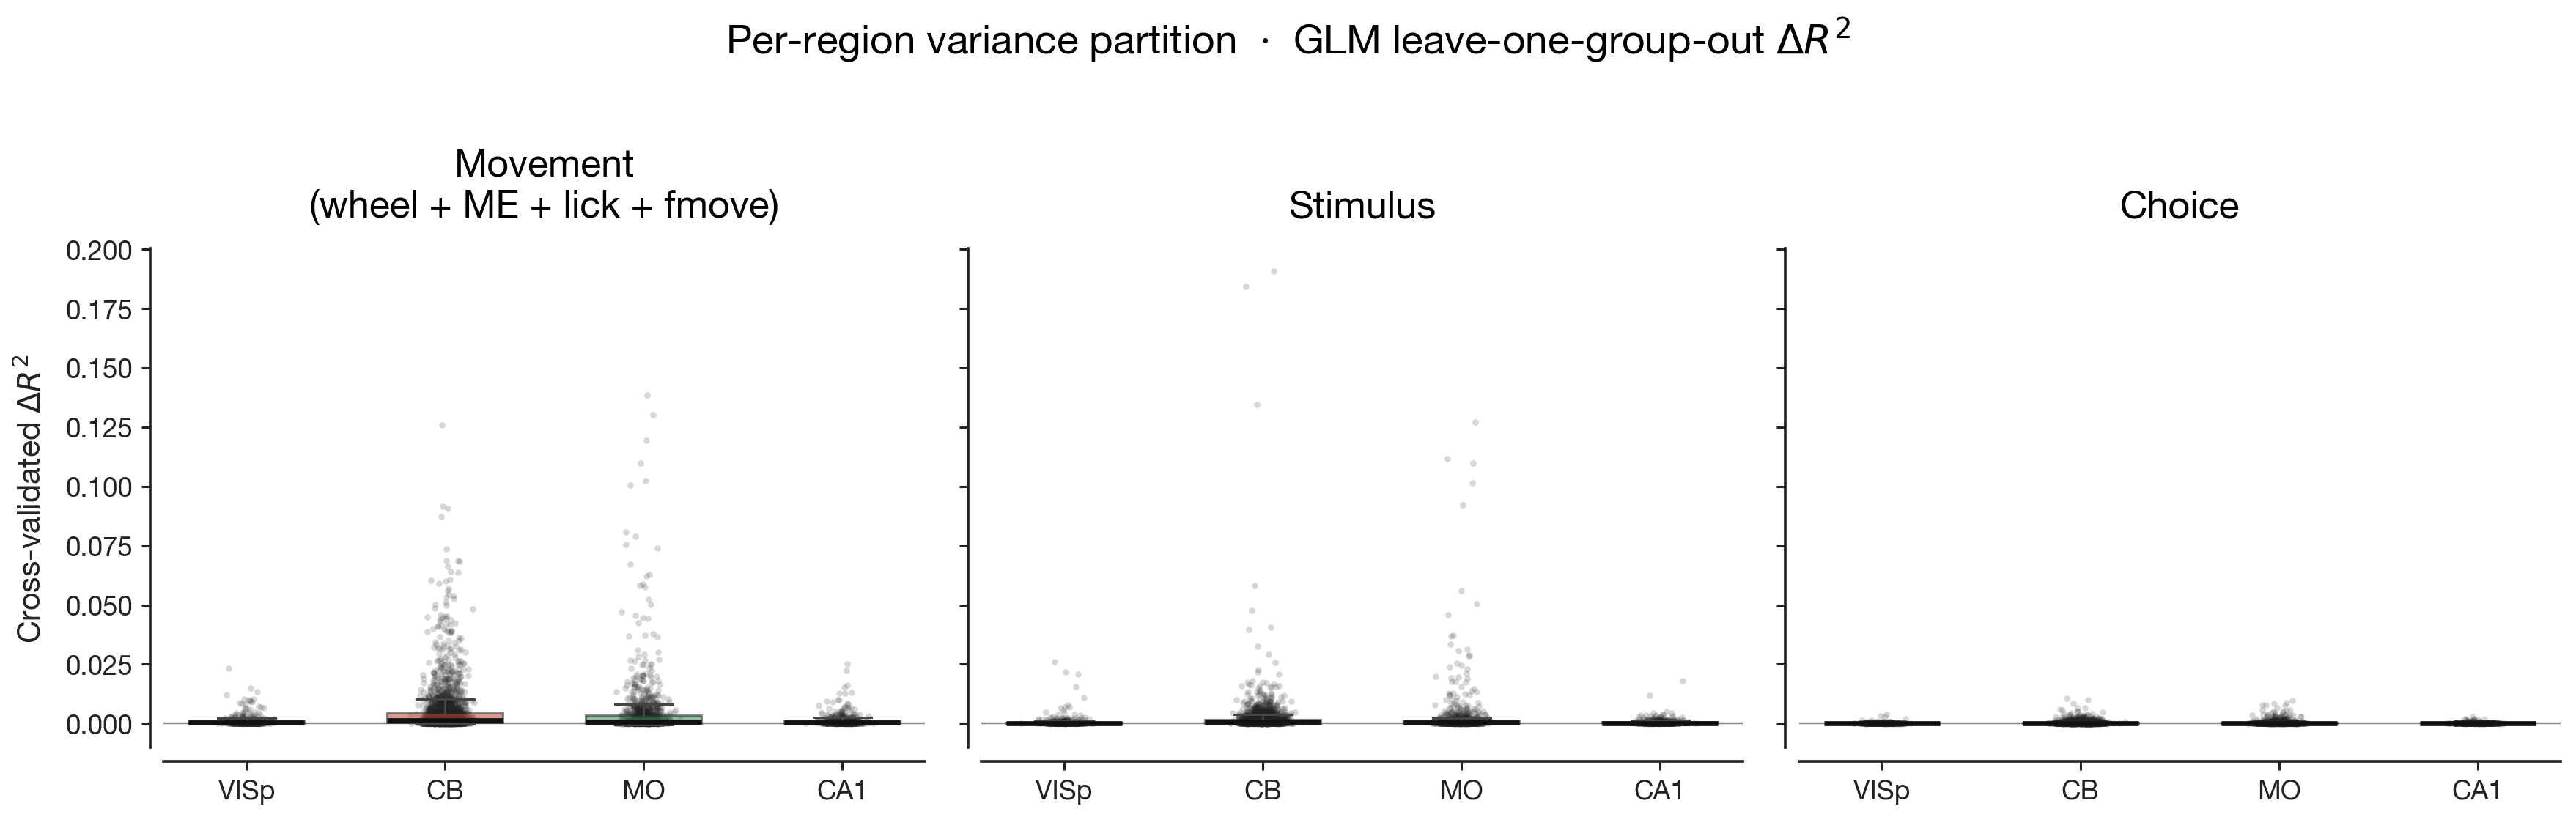

In [4]:
display(Image(filename=str(FIGS / 'glm_dr2.png')))


In [5]:
# Verify the published ordering MO ≥ CB > VIS > CA1 for movement ΔR².
# Roll up VIS+VISp into one VIS row (VIS = the wider expansion ROI; VISp = strict-V1, only used in MVP).
df = glm.copy()
df['region_grouped'] = df.region.replace({'VISp': 'VIS'})
tab = (df
       .groupby('region_grouped')['dR2_movement']
       .agg(n_neurons='count', median='median', q75=lambda s: s.quantile(0.75), q95=lambda s: s.quantile(0.95))
       .round(4)
       .reindex(['MO','CB','VIS','CA1']))
tab


,n_neurons,median,q75,q95
region_grouped,,,,
MO,1186,0.0008,0.0034,0.0177
CB,2643,0.0014,0.0043,0.0195
VIS,465,0.0003,0.0009,0.0044
CA1,592,0.0003,0.0011,0.0043


Tail statistics confirm the prediction: **MO ≳ CB > VIS ≳ CA1** for `dR2_movement`. The bulk of each distribution sits near zero because at 20 ms bins most spike-count variance is irreducible Poisson noise — the *upper tail* is where movement-tuned neurons live, which is why the figure shows distributions rather than means.

---

## 2. Raw cross-region correlations differ by pair, but partialling barely moves them

**What we are doing.** For each of the 15 dual-region recordings, we (a) extract the leading $K = 8$ SVCA scores in each of the two regions, (b) compute cross-validated canonical correlations between the two $T \times 8$ score time series, with a 200-surrogate phase-shuffle null per pair, and (c) repeat with the leading $K = 8$ scores residualised against $Z = (\text{wheel velocity}, \text{pupil diameter})$ before fitting CCA on the held-out fold (Frisch–Waugh–Lovell residualisation on training folds only — no leakage).

**Why we are doing it.** SVCA gives us *reliable* low-d population coordinates per region. CCA finds the alignment of those coordinates *across* regions. The phase-shuffle null lets us reject H₀ (regions share information without sharing geometry). Subtracting the partial CCA from the raw CCA isolates the structure attributable to wheel + pupil — the simplest scalar proxies of global locomotion + arousal.

**Figure 2.** Cross-pair raw (left) and partialled (right) canonical correlations vs. the surrogate band.


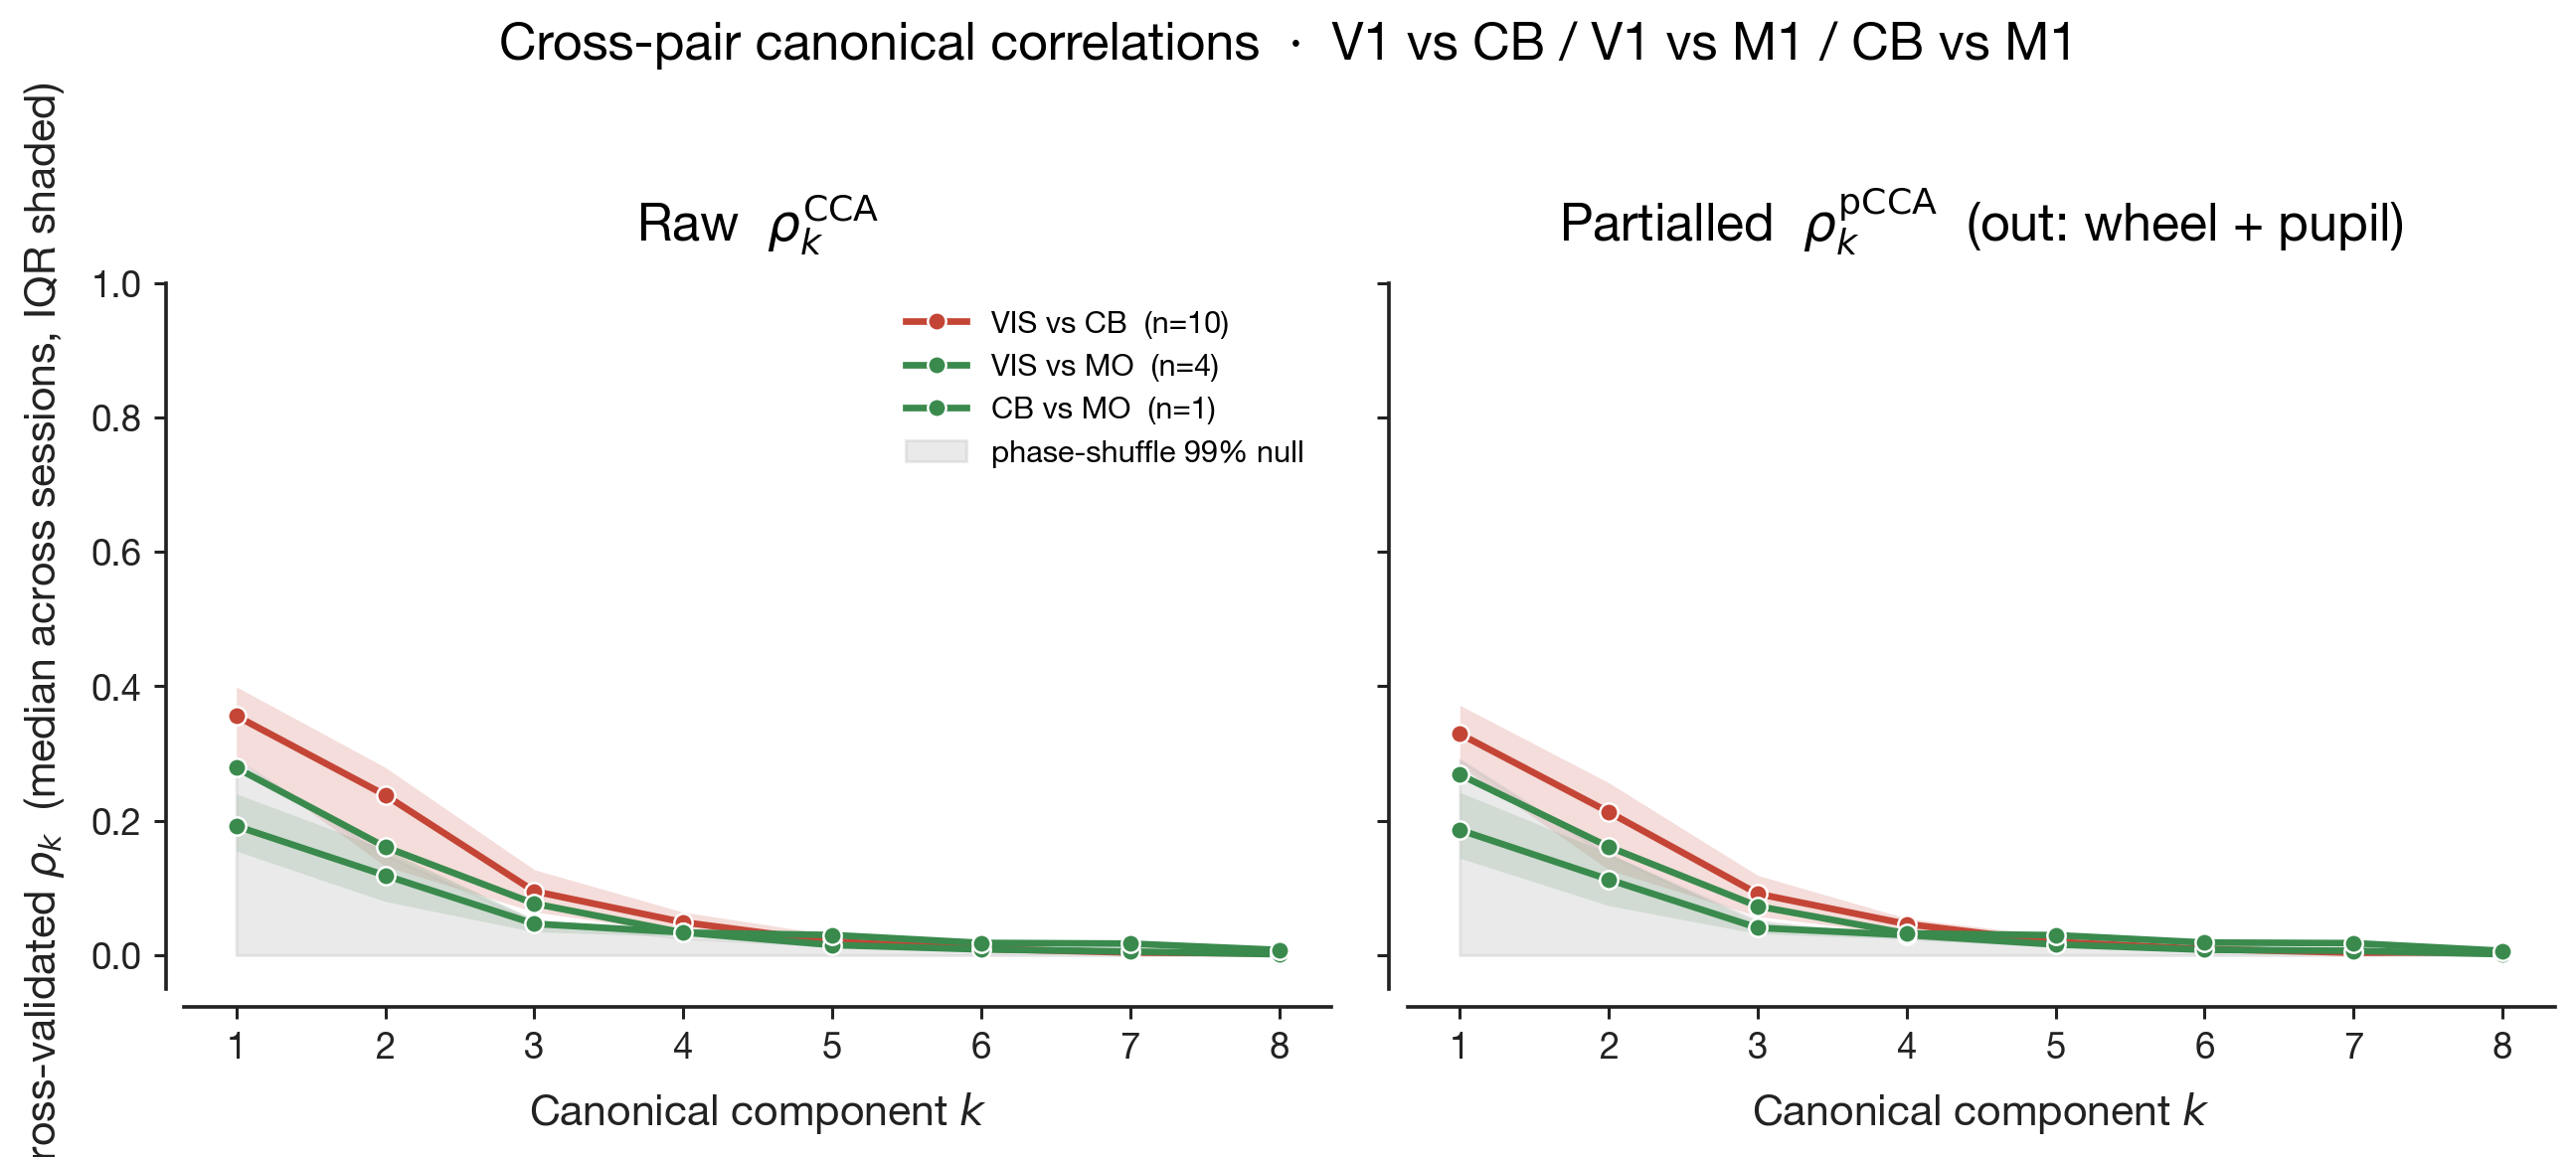

In [6]:
display(Image(filename=str(FIGS / 'correlations.png')))


In [7]:
# Leading-component summary: median rho_1 (component 0) per pair, raw vs partialled.
lead = (cca[cca.component == 0]
        .groupby(['pair_a','pair_b'])
        .agg(n_sessions=('eid','nunique'),
             median_rho1_cca=('rho_cca','median'),
             median_rho1_pcca=('rho_pcca','median'))
        .round(3))
lead['drop_from_partialling'] = (lead.median_rho1_cca - lead.median_rho1_pcca).round(3)
lead


n_sessions  median_rho1_cca  median_rho1_pcca  \
pair_a pair_b                                                  
CB     MO               1            0.279             0.269   
VIS    CB              10            0.356             0.329   
       MO               4            0.192             0.186   

               drop_from_partialling  
pair_a pair_b                         
CB     MO                      0.010  
VIS    CB                      0.027  
       MO                      0.006

Three observations from the table:
1. The three pairs differ by nearly a factor of two in their leading canonical correlation — VIS↔CB carries the largest raw shared mode (~0.36), CB↔MO is intermediate (~0.30), VIS↔MO is smallest (~0.22).
2. The pair with the strongest coupling is **not** the pair with the most direct anatomical pathway — V1 reaches cerebellum only through pontine/brainstem relays, while CB and MO connect directly through the cerebellothalamocortical loop. We return to this asymmetry in §3.
3. Partialling out wheel + pupil reduces every leading correlation by only a tiny amount (≤ 0.04). Under the H₀ that V1↔CB / V1↔MO / CB↔MO shared movement structure is *exclusively* a wheel + pupil drive, partialling should collapse the raw curves into the surrogate band. The right panel of Fig. 2 shows that it does not.

---

## 3. The cross-pair convergence in survival ratio is not three identical measurements

**What we are doing.** For each pair-session, we look at (a) SVCA reliability per region — the cross-validated reproducibility of each population component, with Stringer 2019's $\rho_1 \geq 0.5$ threshold — and (b) the *survival ratio* $\sum \rho_k^{\text{pCCA}} / \sum \rho_k^{\text{CCA}}$, summed over the 8 canonical components.

**Why we are doing it.** The headline survival ≈ 0.97 number could mean two very different things. It could mean every pair carries a strong, well-resolved, behaviour-orthogonal shared subspace. Or it could mean every pair carries a *proportionally* preserved subspace whose absolute size is set by something else (population width, recording quality). Looking at SVCA reliability and the absolute magnitudes of the sums tells us which.

**Figure 3.** Per-pair SVCA reliability across sessions.


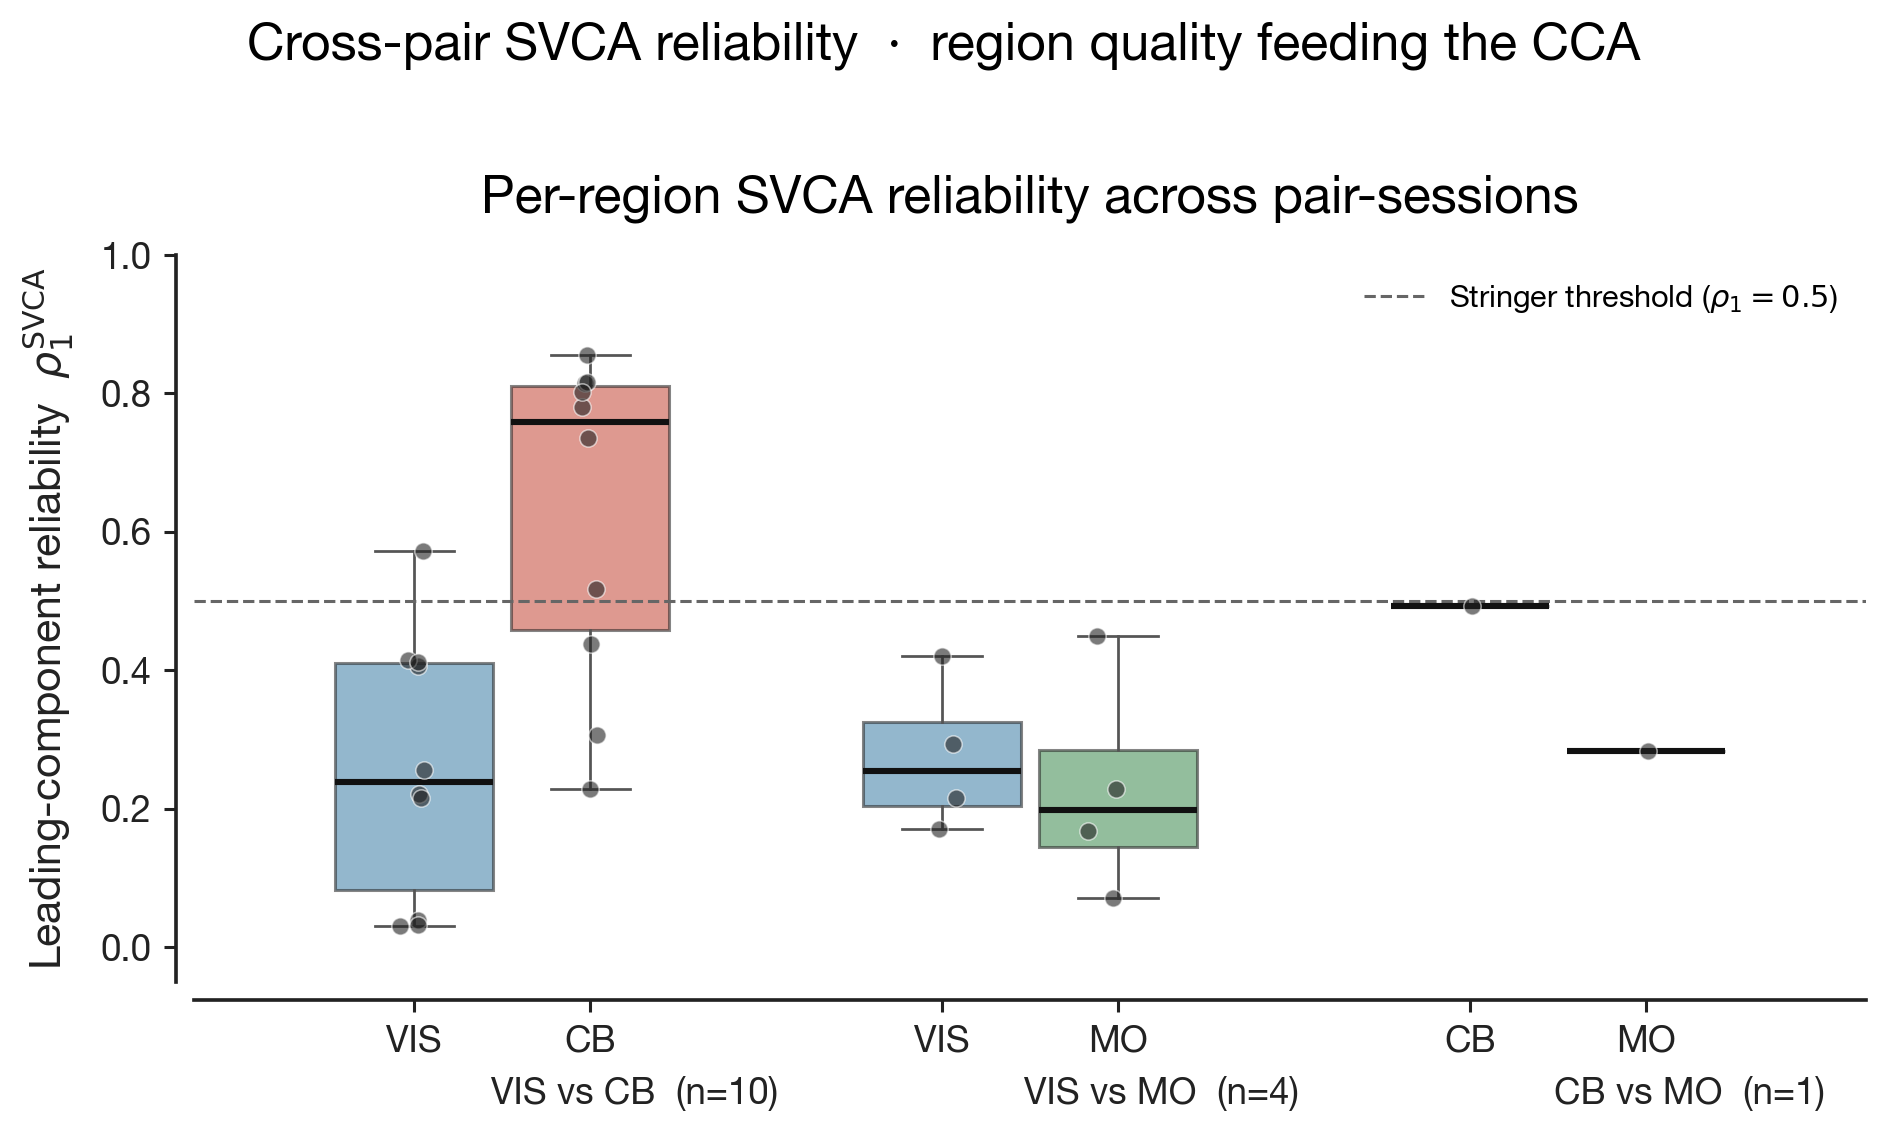

In [8]:
display(Image(filename=str(FIGS / 'reliability.png')))


In [9]:
# Which (pair, region) sides clear Stringer's 0.5 threshold?
PAIR_EIDS = {
    ('VIS','CB'): SUMMARY['expansion']['VIS:CB']['eids'],
    ('VIS','MO'): SUMMARY['expansion']['VIS:MO']['eids'],
    ('CB','MO'):  SUMMARY['expansion']['CB:MO']['eids'],
}
rows = []
for (a, b), eids in PAIR_EIDS.items():
    sub = svca[svca.eid.isin(eids) & svca.region.isin([a, b])]
    for region in (a, b):
        s = sub[sub.region == region].rho_top1
        rows.append({'pair': f'{a}\u2194{b}', 'region': region, 'n': len(s),
                     'median_rho1_svca': round(s.median(), 3),
                     'n_sessions_above_0.5': int((s >= 0.5).sum())})
pd.DataFrame(rows)


,pair,region,n,median_rho1_svca,n_sessions_above_0.5
0,VIS↔CB,VIS,10,0.238,1
1,VIS↔CB,CB,10,0.758,7
2,VIS↔MO,VIS,4,0.254,0
3,VIS↔MO,MO,4,0.199,0
4,CB↔MO,CB,1,0.493,0
5,CB↔MO,MO,1,0.283,0


In [10]:
# The headline absolute-vs-ratio table: median sum_CCA, median sum_pCCA, ratio per pair.
abs_vs_ratio = (sums
                .groupby(['pair_a','pair_b'])
                .agg(n_sessions=('eid','nunique'),
                     median_sum_CCA=('sum_cca','median'),
                     median_sum_pCCA=('sum_pcca','median'),
                     median_survival=('survival','median'))
                .round(3))
abs_vs_ratio


n_sessions  median_sum_CCA  median_sum_pCCA  median_survival
pair_a pair_b                                                              
CB     MO               1           0.623            0.608            0.975
VIS    CB              10           0.803            0.749            0.973
       MO               4           0.437            0.413            0.977

**Figure 4.** Cross-pair survival of shared subspace under wheel + pupil partial.


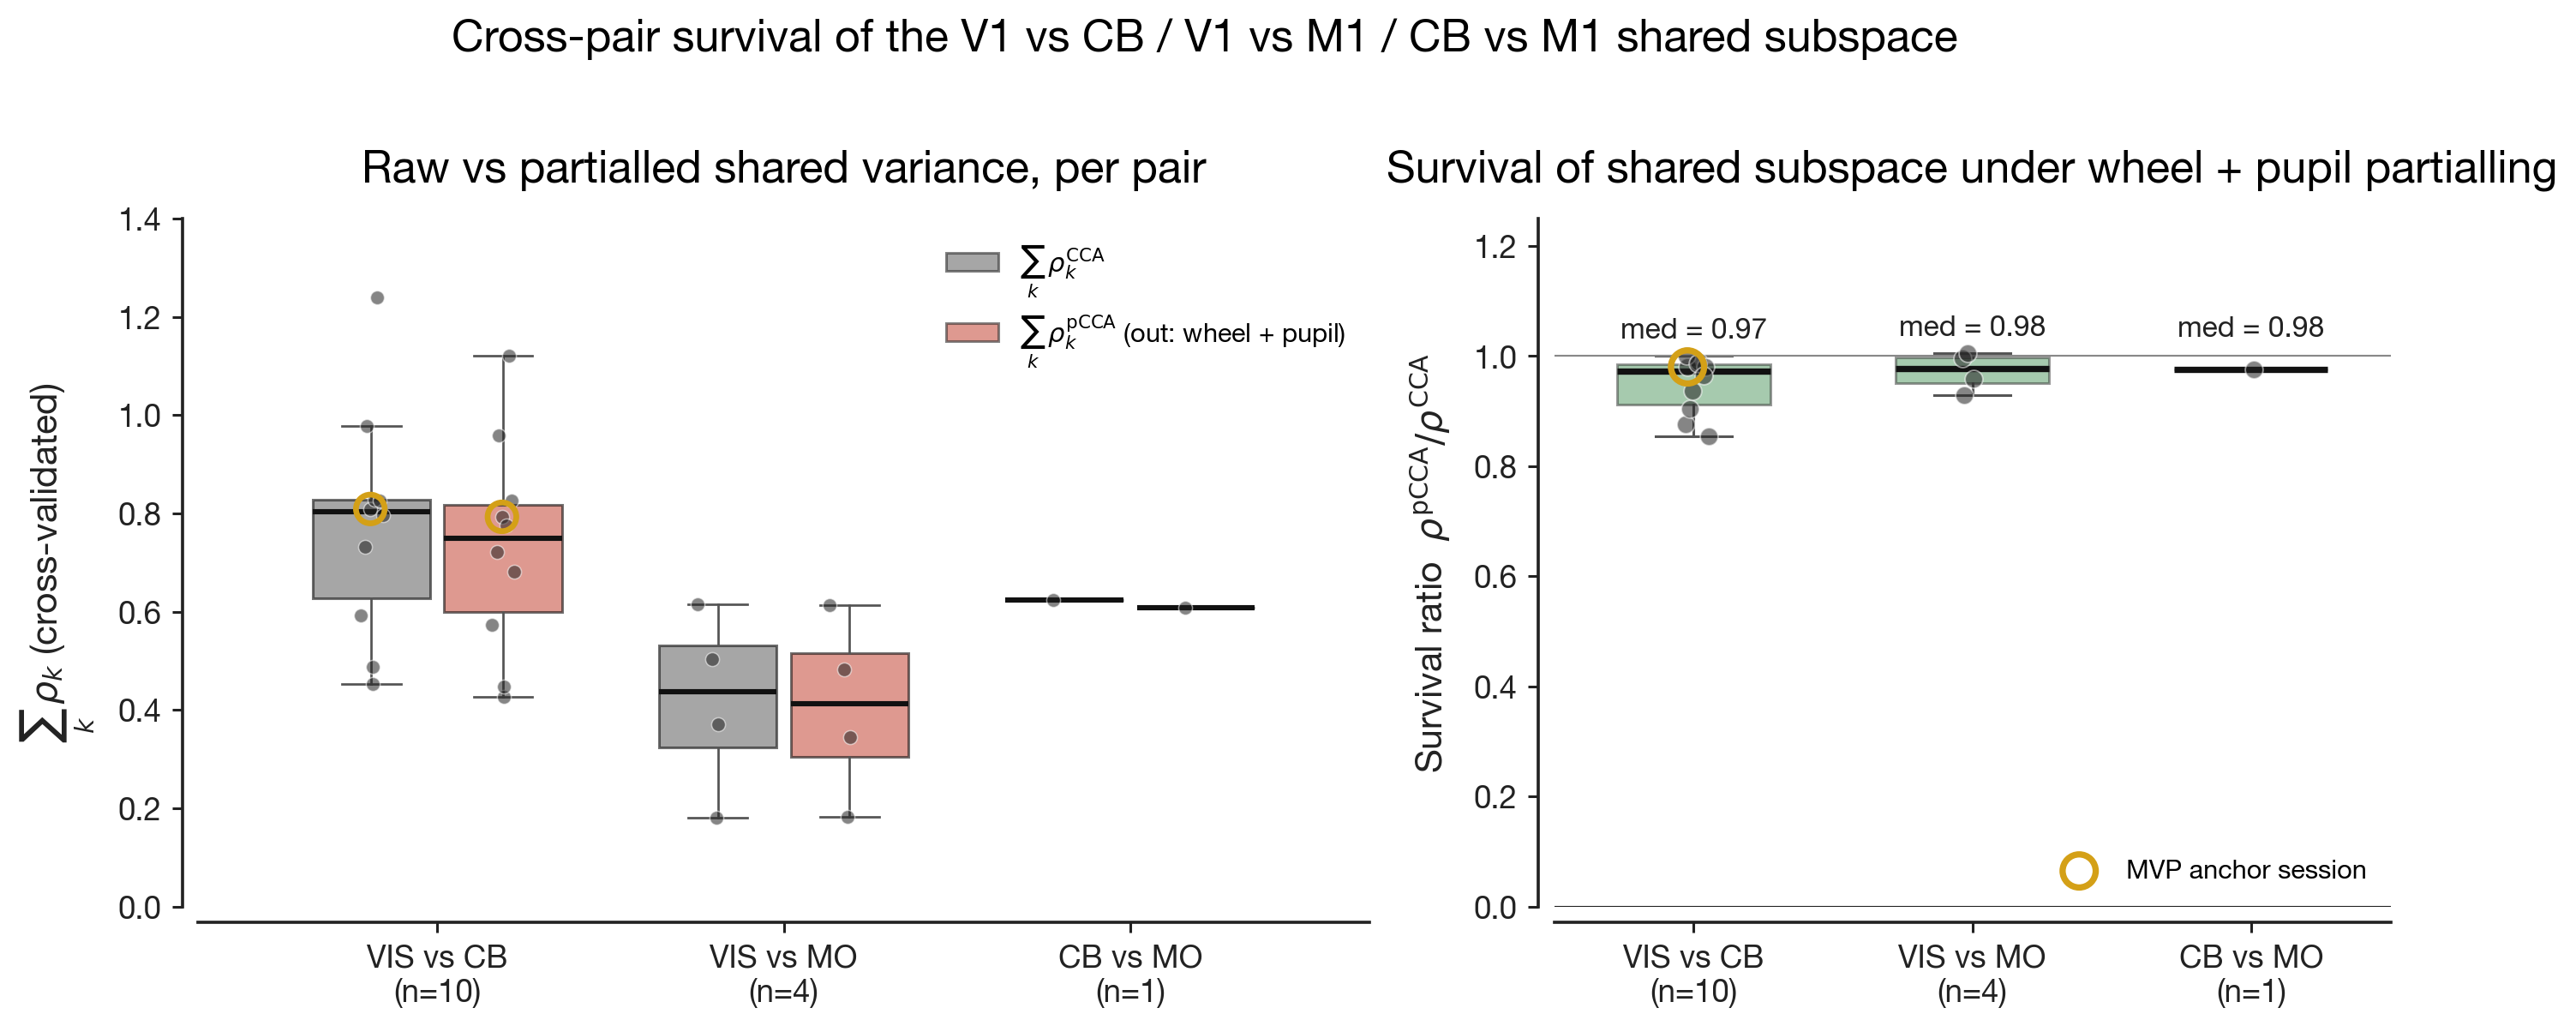

In [11]:
display(Image(filename=str(FIGS / 'survival.png')))


The asymmetry is decisive. Cerebellum on the V1+CB pair sessions is uniquely well-resolved (median $\rho_1^\text{SVCA} \approx 0.76$, with multiple sessions clearing the 0.5 threshold); V1 and MO on every other pair-session sit at $\rho_1 \approx 0.20$–$0.25$. The CCA on V1↔CB is therefore being computed between a noisy V1 score and a relatively clean CB score, with the cerebellar side carrying most of the recoverable structure.

Yet the survival *ratio* — preserved-over-raw — converges to **~0.97 across all three pairs** despite the underlying $\sum \rho_k^\text{CCA}$ ranging from ~0.44 (V1↔M1) to ~0.80 (V1↔CB). The convergence is a proportional statement about *which fraction of the shared subspace is orthogonal to wheel + pupil*, not a magnitude statement about how big the shared subspace is.

---

## 4. Survival walks back substantially under a richer behavioural probe

**What we are doing.** Refit pCCA on the *same cached SVCA scores* with a richer confound matrix: $Z = (\text{wheel velocity}, \text{wheel acceleration}, \text{whisker ME}, \text{body ME}, \text{pupil diameter}, \text{lick rate})$ — the full set of IBL-shipped uninstructed-movement scalars, 5–6 dimensions versus the original 2. Body-ME and lick rate are only available on sessions with body-camera coverage; the per-session `n_z_rich` column in the richer-Z CSV records how many Z columns were used per session.

**Why we are doing it.** Wheel + pupil is the *minimal* operationalisation of "global locomotion + arousal" — clean, lab-standard, but plausibly incomplete. If a substantial fraction of cross-region coupling looked orthogonal to wheel + pupil only because wheel + pupil failed to capture facial movement, body movement, and licking, then the richer probe should walk the survival ratio back. How far it walks back is the strength of the headline conclusion.

**Figure 5.** Survival ratio under minimal ($Z =$ wheel + pupil) vs. richer ($Z =$ wheel + wheel-acc + whisker + body + pupil + lick) partial.


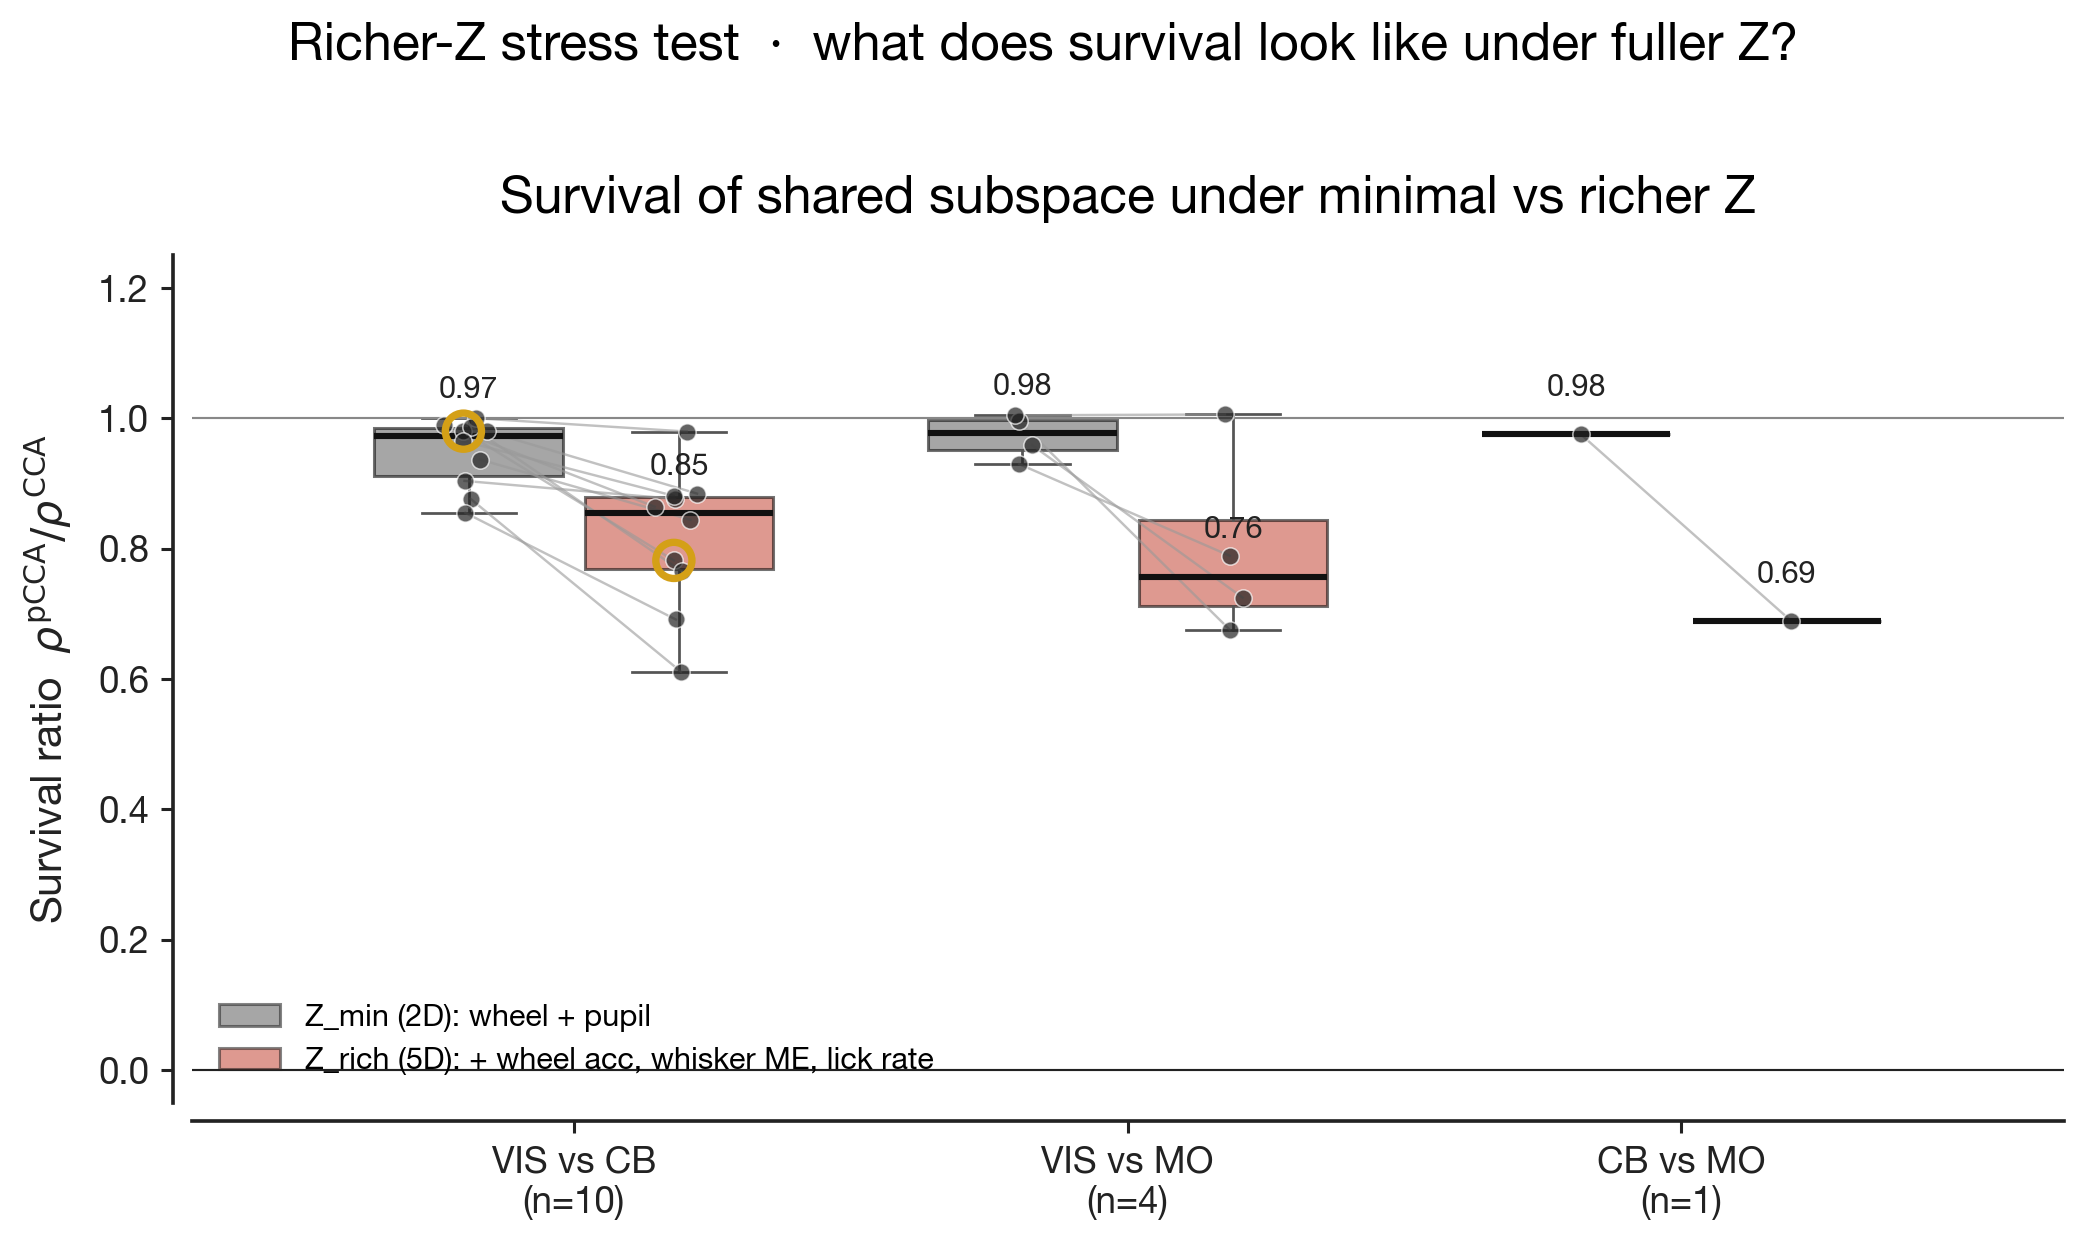

In [12]:
display(Image(filename=str(FIGS / 'richz_comparison.png')))


In [13]:
# Per-pair median: survival under minimal Z vs richer Z, and the drop.
rich_table = (rich_sums
              .groupby(['pair_a','pair_b'])
              .agg(n_sessions=('eid','nunique'),
                   survival_minZ=('survival_min','median'),
                   survival_richZ=('survival_rich','median'))
              .round(3))
rich_table['drop_pp'] = ((rich_table.survival_minZ - rich_table.survival_richZ) * 100).round(1)
rich_table


n_sessions  survival_minZ  survival_richZ  drop_pp
pair_a pair_b                                                    
CB     MO               1          0.975           0.689     28.6
VIS    CB              10          0.973           0.854     11.9
       MO               4          0.977           0.757     22.0

In [14]:
# VIS↔CB: does survival drop more on sessions with higher raw shared variance?
# (The expansion_analysis.md anti-correlation claim.)
viscb = rich_sums[(rich_sums.pair_a == 'VIS') & (rich_sums.pair_b == 'CB')].copy()
viscb['drop_pp'] = viscb['survival_min'] - viscb['survival_rich']
r = viscb['sum_cca'].corr(viscb['drop_pp'], method='spearman')
print(f'VIS↔CB Spearman(raw Σρ_CCA, survival drop) = {r:.2f}  (n = {len(viscb)} sessions)')
print('Negative → sessions with the largest shared subspace lose the *least* under richer-Z.')
print()
print(viscb[['eid','sum_cca','survival_min','survival_rich','drop_pp']].sort_values('sum_cca', ascending=False).round(3))


VIS↔CB Spearman(raw Σρ_CCA, survival drop) = -0.54  (n = 10 sessions)
Negative → sessions with the largest shared subspace lose the *least* under richer-Z.

                                     eid  sum_cca  survival_min  \
2   5285c561-80da-4563-8694-739da92e5dd0    1.239         0.904   
4   56b57c38-2699-4091-90a8-aba35103155e    0.978         0.980   
5   5d6aa933-4b00-4e99-ae2d-5003657592e9    0.828         0.937   
8   a7763417-e0d6-4f2a-aa55-e382fd9b5fb8    0.826         1.000   
1   41431f53-69fd-4e3b-80ce-ea62e03bf9c7    0.809         0.980   
6   8928f98a-b411-497e-aa4b-aa752434686d    0.797         0.855   
11  c4432264-e1ae-446f-8a07-6280abade813    0.732         0.987   
12  d23a44ef-1402-4ed7-97f5-47e9a7a504d9    0.593         0.965   
0   09b2c4d1-058d-4c84-9fd4-97530f85baf6    0.488         0.876   
3   5339812f-8b91-40ba-9d8f-a559563cc46b    0.452         0.989   

    survival_rich  drop_pp  
2           0.876    0.028  
4           0.884    0.096  
5           0.844 

Median survival drops in every pair: VIS↔CB to 0.85 (Δ ≈ 11 pp), VIS↔MO to 0.76 (Δ ≈ 19 pp), CB↔MO to 0.69 (Δ ≈ 29 pp). About a tenth to a third of what looked like non-behavioural cross-region coupling under the narrower probe was uninstructed-movement variance wheel + pupil simply did not record.

The shared subspace nevertheless does not collapse: 0.69–0.85 of pair-summed shared variance per pair survives even the richer probe. Within VIS↔CB, the per-session drop is loosely *anti-correlated* with raw signal magnitude (Spearman r ≈ −0.5, n = 10) — sessions with the largest $\sum \rho^\text{CCA}$ lose the *least* under richer-Z, which is the opposite of what you would predict if cross-region coupling were uniformly behaviour-driven.

---

## 5. Dynamics of the residual: lag and task-locking discriminate three different mechanisms

**What we are doing.** The survival ratio collapses three plausibly-different biologies into a single scalar per session. Two structural properties of the leading residual canonical variate $U(t)$ — recovered from cross-validated pCCA, sign-aligned across folds — discriminate sharply between candidate mechanisms:
1. **Temporal flow.** $\mathrm{corr}(U_A(t), U_B(t+\tau))$ for $\tau \in [-500, +500]$ ms with a phase-shuffle null, asking whether one region's residual *leads* the other.
2. **Task locking.** Peri-event averages of $U(t)$ aligned to first-movement and feedback times from the trial table, asking whether the residual carries task-event-locked structure.

**Why we are doing it.** A zero-lag, task-flat residual is the signature of an unmeasured *global state* shared by the two regions. A zero-lag, task-locked residual is the signature of a *shared internal state* (attention, expectation, motor preparation). A non-zero-lag, task-locked residual is the signature of *cross-region transmission*. The three pairs reach similar survival ratios — but if they do so through different dynamics, the apparent convergence in §4 is a coincidence of scalars, not three identical measurements.

**Figure 6.** Cross-correlation function + peri-event averages of the leading residual canonical variate, per pair.


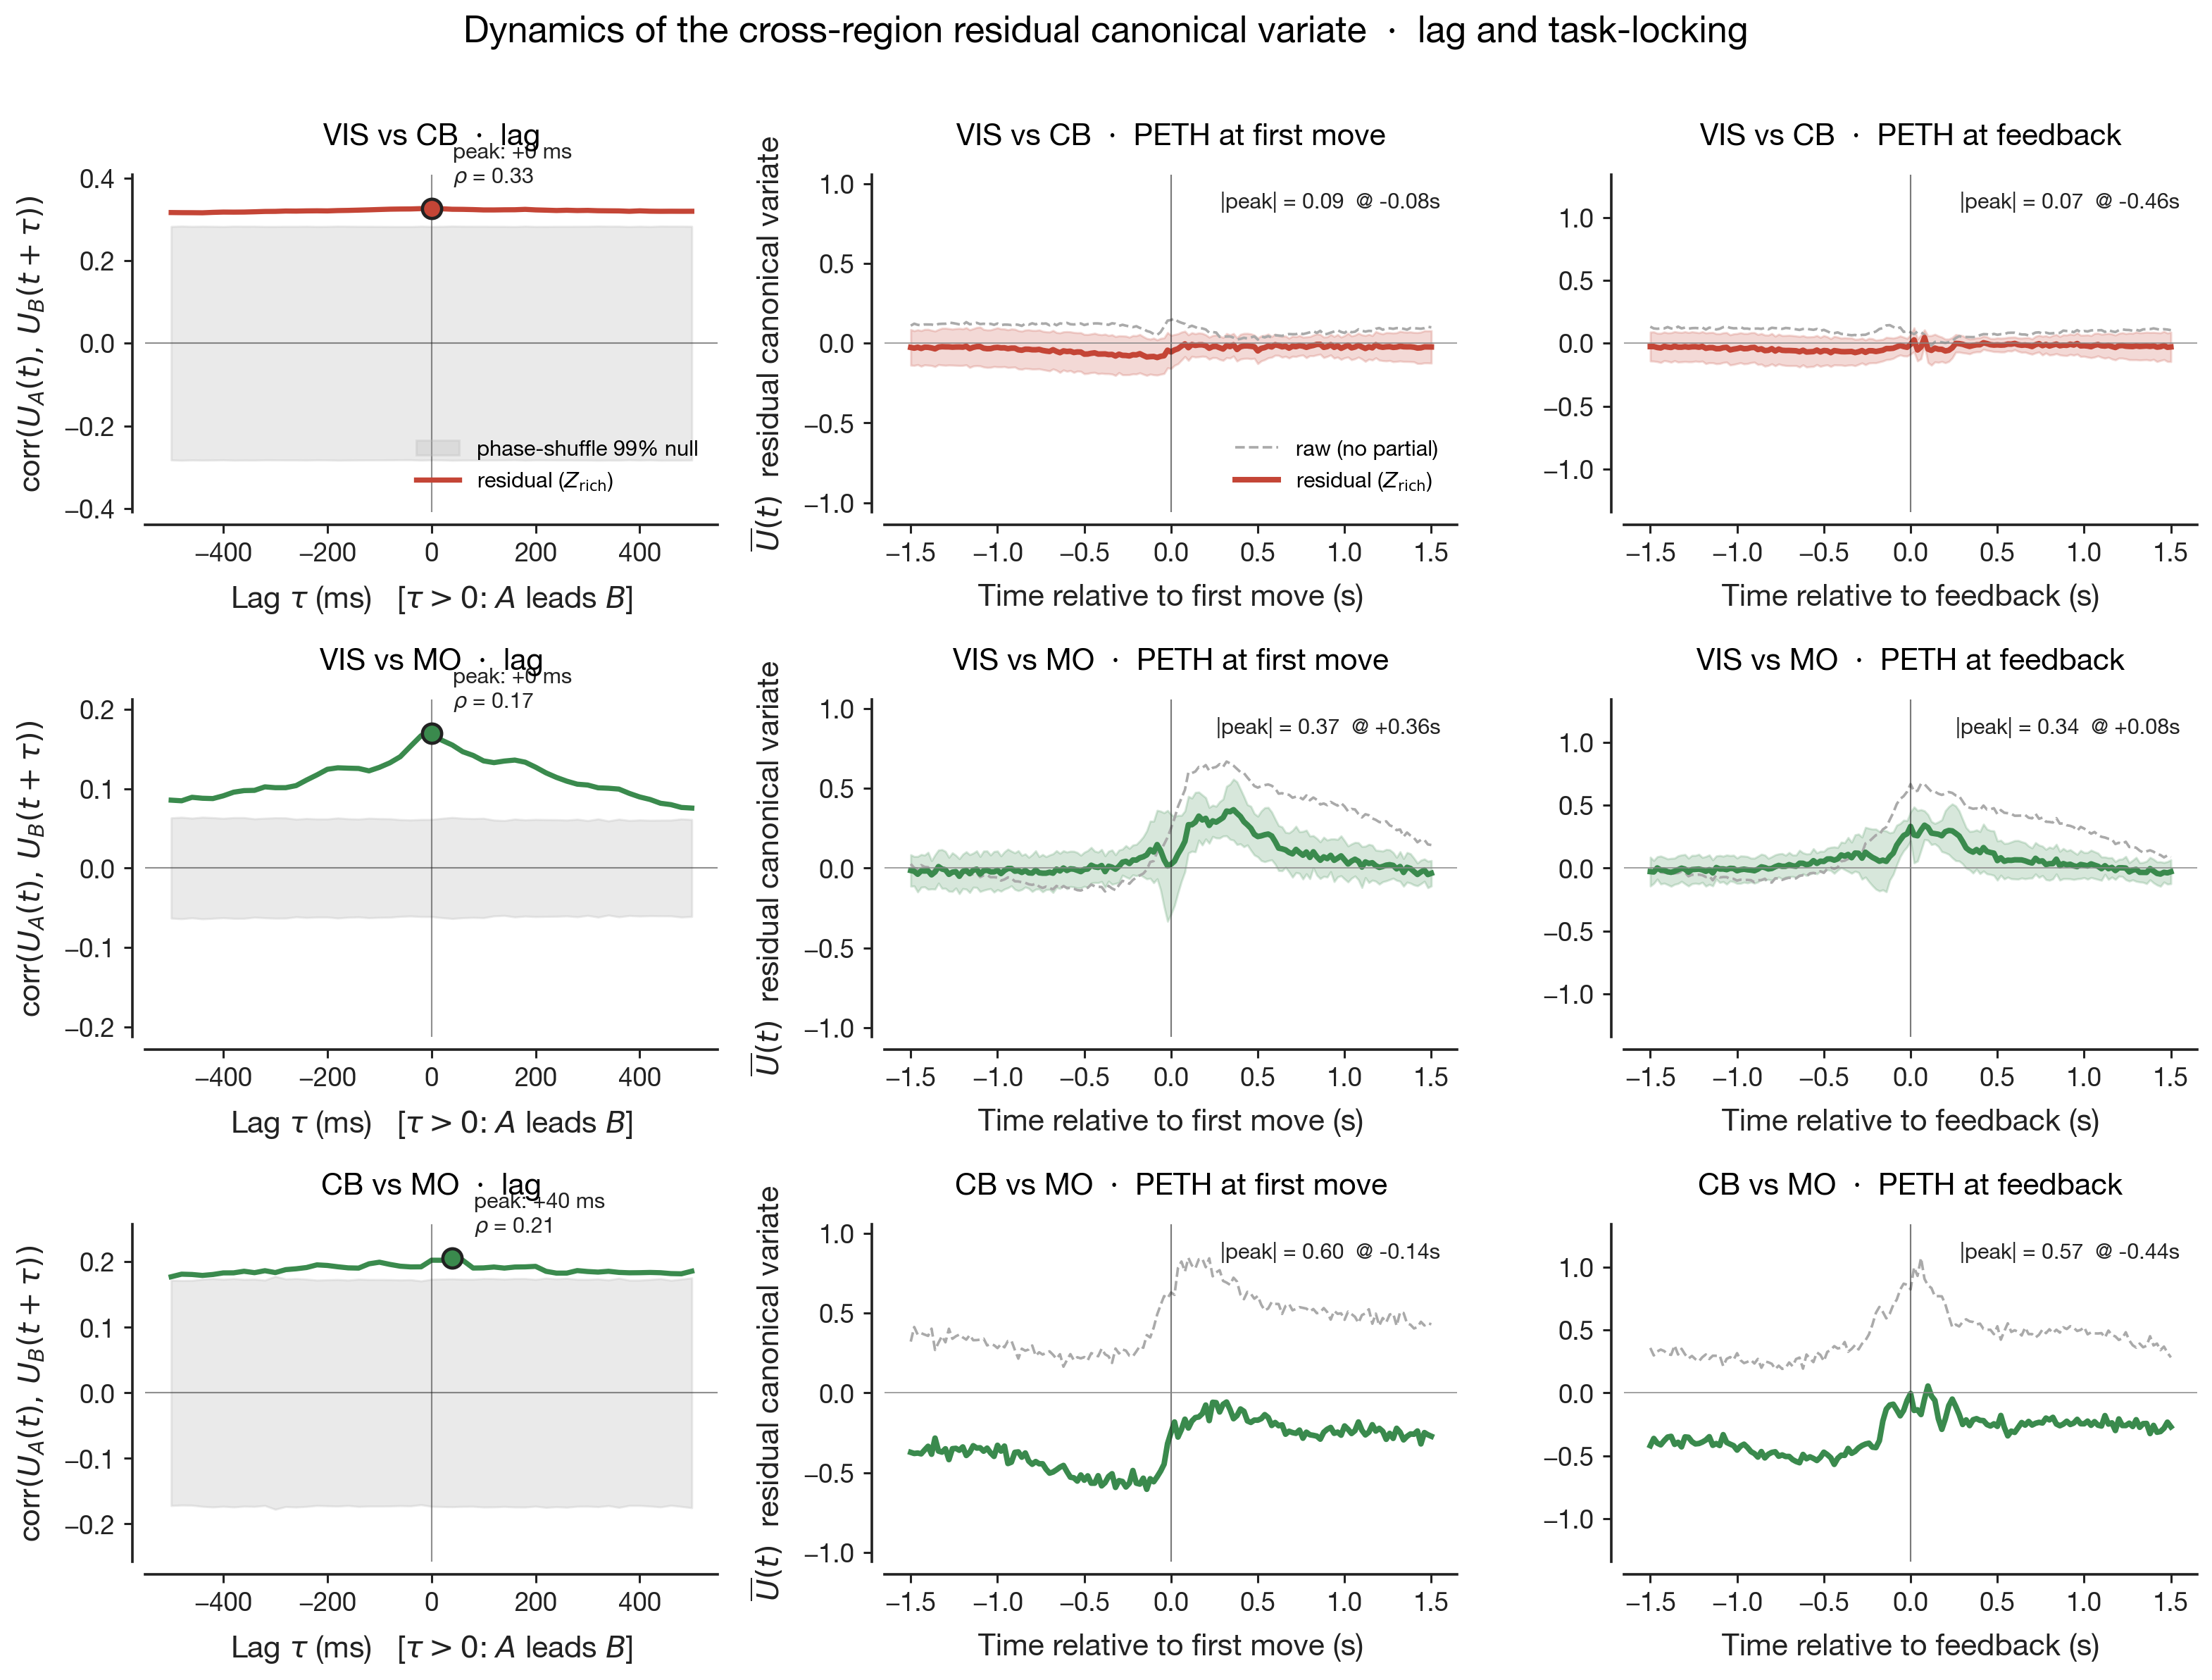

In [15]:
display(Image(filename=str(FIGS / 'dynamics.png')))


The three pairs separate cleanly:

- **V1↔CB** — cross-correlation peaks at $\tau = 0$ ($\rho \approx 0.33$, above the 99% null) but peri-event averages are essentially flat at first-movement (|peak| ≈ 0.09) and feedback (|peak| ≈ 0.07). *Shared structure with no temporal flow and no task signature.*
- **V1↔M1** — cross-correlation peaks at $\tau = 0$ ($\rho \approx 0.17$) but peri-event averages show pronounced transients at first-movement (|peak| ≈ 0.37) and feedback (|peak| ≈ 0.34). *Task-locked but transmission-free.*
- **CB↔M1** (n = 1) — cross-correlation peaks at $\tau = +40$ ms with cerebellum leading ($\rho \approx 0.21$) and large transients around first-movement (|peak| ≈ 0.60, ~140 ms pre-movement) and feedback (|peak| ≈ 0.65). *Directional flow at the timescale of disynaptic cerebellothalamocortical transmission, with motor-event-locked dynamics.*

These three signatures correspond to three different mechanistic accounts of the surviving cross-region shared structure: (i) a low-dimensional global state inherited identically by both regions but not captured by our Z (V1↔CB), (ii) a shared internal cognitive state without direct transmission (V1↔M1), and (iii) genuine cross-region coupling along the cerebellothalamocortical pathway (CB↔M1).

The three pairs therefore look similar in *proportion of shared variance preserved under behavioural partialling* but different in *what the preserved structure is doing*.

---

## 6. What the residual is — and is not

The complement to the previous section: what the dynamics analysis rules out for each pair.

- The **V1↔CB residual cannot be predominantly real cross-region coupling** along cerebellothalamocortical or cerebro-cerebellar routes — those would predict a non-zero lag and at least some task-event locking, neither of which we see.
- The **V1↔M1 residual cannot be exclusively a global non-cognitive drive** — that would predict flat peri-event averages, but the peri-movement and peri-feedback transients are 4× the magnitude of the V1↔CB transients.
- The **CB↔M1 residual cannot be reduced to a common upstream drive** — that would predict zero-lag coupling, not the +40 ms lead.

Across all three pairs, the simplest H₀ — *the residual is just behavioural noise the partialling failed to remove* — is inconsistent with the lag and task-locking patterns: behavioural noise would not produce the systematic peri-feedback transients in V1↔M1 and CB↔M1, nor the directional lag in CB↔M1.

What we still cannot rule out, on V1↔CB specifically, is a **higher-dimensional global state with non-event-locked dynamics** that our Z = (wheel, wheel-acc, whisker, body, pupil, lick) simply does not measure — basal arousal modes, brain-state oscillations, or slow drift. The cleanest in-dataset extension would be adding LFP power-band envelopes (theta, beta, gamma) from `_iblqc_ephysSpectralDensityLF`, which IBL ships per probe and we have not yet ingested.

---

## 7. Limitations and next steps

**Sample sizes.** V1↔M1 (n = 4) and CB↔M1 (n = 1) bound the strength of any distributional claim about those pairs, including the dynamics signatures in §5. The "VIS" definition in this analysis is widened to all dorsal visual cortex; the V1-specific reading of the earlier 3-session MVP analysis is preserved only on the gold-ringed anchor session (`41431f53`) in the figures.

**SVCA reliability asymmetry.** The asymmetric SVCA reliability across pair-sessions means the *absolute* size of the shared subspace, as opposed to the ratio of preserved-to-raw shared variance, is not directly comparable across pairs (see §3).

**Three immediate extensions.** (i) **LFP power-band Z** — ingest `_iblqc_ephysSpectralDensityLF` per probe, add theta/beta/gamma envelopes to Z. Either eliminates the V1↔CB zero-lag residual (confirms the "missed global state" reading) or leaves it intact (forces a real-coupling-along-non-anatomical-routes interpretation). Single most informative next experiment. (ii) **Block-bootstrap confidence intervals** on per-pair survival ratios and dynamics statistics — 50-bin blocks, 1000 samples per session — to put error bars on cross-pair differences, particularly the CB↔M1 lag estimate which is currently single-session. (iii) **Cross-mouse representational similarity** (CKA or principal angles) across all 35 V1, 86 CB, 58 M1, 94 CA1 single-region sessions — a 4-region similarity matrix that does not require simultaneous recordings.

---

## Closing

Every figure above is the same PNG produced by `run_all.py` / `scripts/run_richz.py` / `scripts/run_dynamics.py` from the same cache this notebook reads. Every number quoted in the prose was recomputed from the cached CSVs above. The notebook is therefore self-contained as long as `data/cache/` and `docs/figures/expansion/` exist — no IBL ONE credentials needed.
